In [19]:
# I help myself zith AIqnd my PC has serious problems
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [20]:
#load and plot the data
data = pd.read_csv('data/data_exercice.csv',delimiter=',')
data = data.drop(columns=['SNo'])
data.columns = data.columns.str.strip()
data = data.fillna(data.mean())
print("Cleaned Data:")
print(data.head())



Cleaned Data:
        X_1       X_2    y
0 -0.869144  0.389310  0.0
1 -0.993467 -0.610591  0.0
2 -0.834064  0.239236  0.0
3 -0.136471  0.632003  1.0
4  0.403887  0.310784  1.0


In [22]:
# prepare data
X = data[['X_1', 'X_2']].values
y = data['y'].values

#add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]


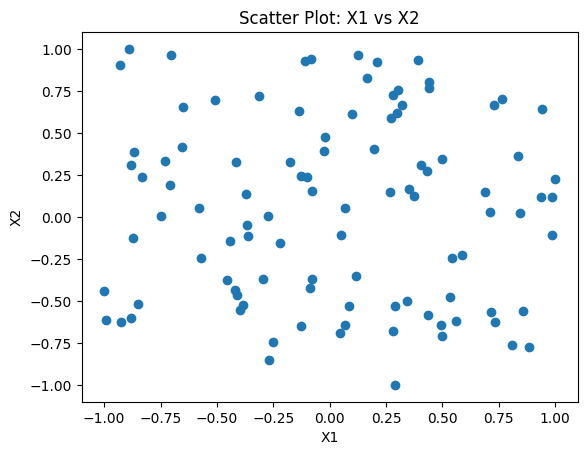

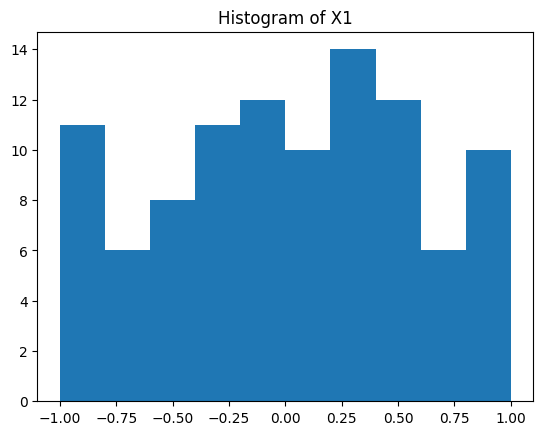

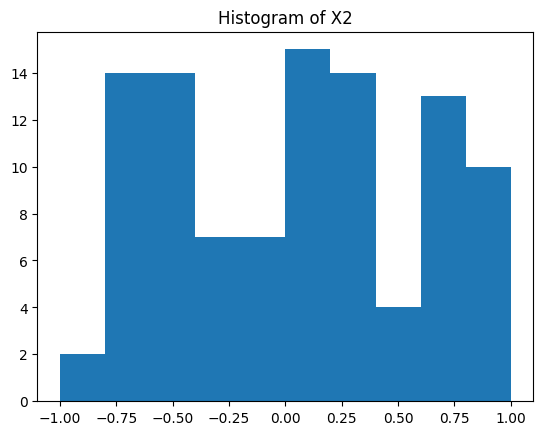

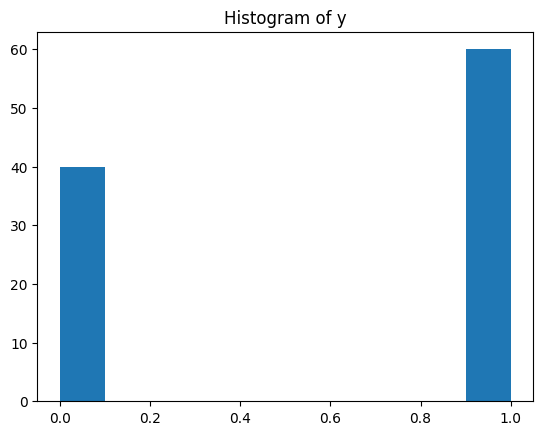

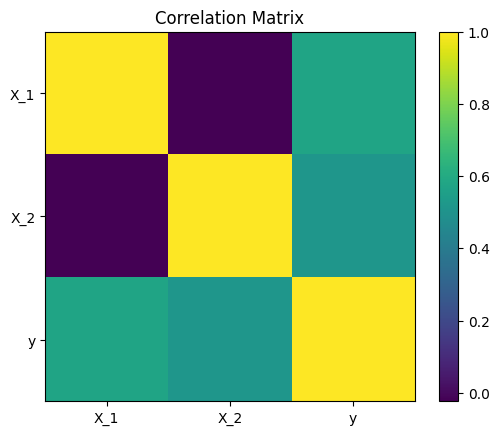

In [24]:
# 4. VISUALIZATION (5 PLOTS)
# =========================================

# 1. Scatter Plot
plt.figure()
plt.scatter(data['X_1'], data['X_2'])
plt.title("Scatter Plot: X1 vs X2")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

# 2. Histogram X1
plt.figure()
plt.hist(data['X_1'])
plt.title("Histogram of X1")
plt.show()

# 3. Histogram X2
plt.figure()
plt.hist(data['X_2'])
plt.title("Histogram of X2")
plt.show()

# 4. Histogram y
plt.figure()
plt.hist(data['y'])
plt.title("Histogram of y")
plt.show()

# 5. Correlation Matrix
plt.figure()
plt.imshow(data.corr())
plt.title("Correlation Matrix")
plt.xticks(range(len(data.columns)), data.columns)
plt.yticks(range(len(data.columns)), data.columns)
plt.colorbar()
plt.show()

In [25]:
# 6. LINEAR REGRESSION FROM SCRATCH
# =========================================

# Normal Equation
theta_linear = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Predictions
y_pred_linear = X_b @ theta_linear

print("\nLinear Regression (Scratch) Coefficients:")
print(theta_linear)


Linear Regression (Scratch) Coefficients:
[0.56888436 0.51771676 0.47588936]


# Logistic Regression

In [26]:
# 7. LOGISTIC REGRESSION FROM SCRATCH
# =========================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize parameters
theta_log = np.zeros(X_b.shape[1])
learning_rate = 0.1
epochs = 1000

# Gradient Descent
for i in range(epochs):
    z = X_b @ theta_log
    h = sigmoid(z)
    gradient = (X_b.T @ (h - y)) / len(y)
    theta_log -= learning_rate * gradient

# Predictions
y_pred_log_prob = sigmoid(X_b @ theta_log)
y_pred_log = (y_pred_log_prob >= 0.5).astype(int)

print("\nLogistic Regression (Scratch) Coefficients:")
print(theta_log)
# Accuracy
acc_log_scratch = accuracy_score(y, y_pred_log)
print("Logistic Regression (Scratch) Accuracy:", acc_log_scratch)


Logistic Regression (Scratch) Coefficients:
[0.68402737 3.84334984 3.56851218]
Logistic Regression (Scratch) Accuracy: 0.89


In [27]:
# 8. SCIKIT-LEARN MODELS
# =========================================

# Linear Regression
model_lr = LinearRegression()
model_lr.fit(X, y)
y_pred_sklearn_lr = model_lr.predict(X)

print("\nScikit-Learn Linear Regression Coefficients:")
print(model_lr.coef_)

# Logistic Regression
model_log = LogisticRegression()
model_log.fit(X, y)
y_pred_sklearn_log = model_log.predict(X)

print("\nScikit-Learn Logistic Regression Coefficients:")
print(model_log.coef_)

# Accuracy
acc_log_sklearn = accuracy_score(y, y_pred_sklearn_log)
print("Logistic Regression (Scikit-learn) Accuracy:", acc_log_sklearn)

# Confusion Matrix
cm = confusion_matrix(y, y_pred_sklearn_log)
print("\nConfusion Matrix:")
print(cm)


Scikit-Learn Linear Regression Coefficients:
[0.51771676 0.47588936]

Scikit-Learn Logistic Regression Coefficients:
[[2.81003262 2.5877695 ]]
Logistic Regression (Scikit-learn) Accuracy: 0.89

Confusion Matrix:
[[34  6]
 [ 5 55]]


In [11]:
costFunction( X , y )

np.float64(0.6931471805599453)

In [12]:
X[:,0].shape

(100,)

In [13]:
def gradientDescent(X, y, theta=[[0], [0], [0]], epochs = 1000, learning_rate = 0.01):
    
    m = y.size
    X_extend = np.c_[np.ones(m),X]
    j_history = []

    n_print = epochs//10

    for i in range(epochs):
        
        z = np.dot(X_extend,theta)
        h = sigmoid(z)
        epsilon = 1e-15  # Small value to prevent log(0)
        # Clip predictions to avoid 0 and 1
        h = np.clip(h, epsilon, 1 - epsilon)
        
        
        theta[0] = theta[0]-learning_rate*(1/m)*np.sum(h-y)
        theta[1] = theta[1]-learning_rate*(1/m)*np.sum((h-y)*X[:,0:1])
        theta[2] = theta[2]-learning_rate*(1/m)*np.sum((h-y)*X[:,1:2])

        j = (-1/m)*np.sum(y*np.log(h)+(1-y)*np.log(1-h))
        j_history.append(j)
        
        if (i+1) % n_print == 0:
            print("Iteration", i+1, " | Cost: ", j, "\n")
    
    return  theta, j_history

In [14]:
theta , j_history = gradientDescent( X , y, epochs=200000 )

Iteration 20000  | Cost:  3.964634613638962 

Iteration 40000  | Cost:  9.908917611930406 

Iteration 60000  | Cost:  6.564667256692252 

Iteration 80000  | Cost:  1.7191355693941335 

Iteration 100000  | Cost:  1.0766535517103955 

Iteration 120000  | Cost:  1.1960002906492202 

Iteration 140000  | Cost:  1.0267772074975205 

Iteration 160000  | Cost:  0.9062097211441211 

Iteration 180000  | Cost:  0.29370148279601543 

Iteration 200000  | Cost:  0.3067150914282908 



In [15]:
theta

[array([-59.81891963]), array([0.49798707]), array([0.49088035])]

Text(0, 0.5, 'Cost value')

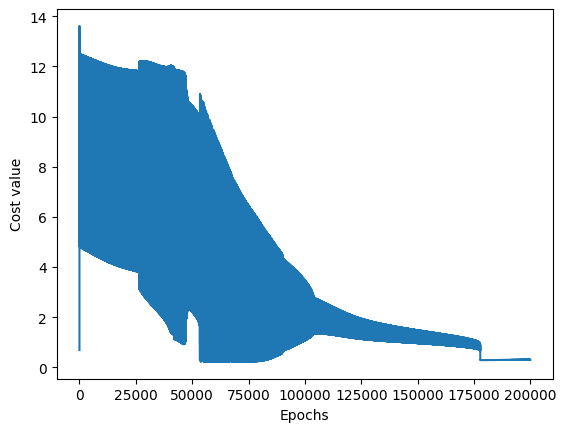

In [17]:
plt.plot( j_history )
plt.xlabel('Epochs')
plt.ylabel('Cost value')

In [18]:
pos = (y == 1).ravel()
neg = (y == 0).ravel()

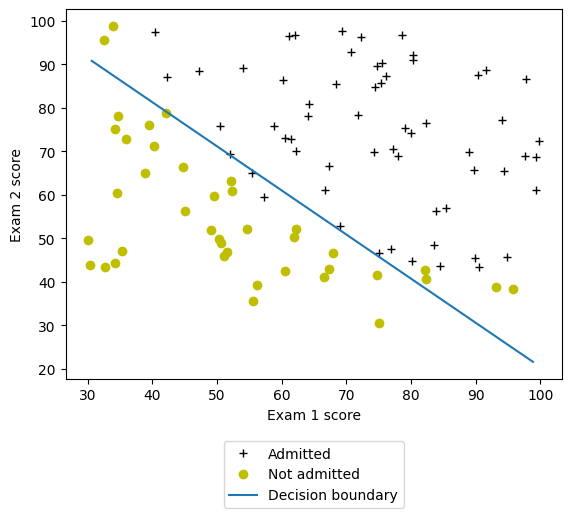

In [19]:
x_plot = np.array((X[:, 1].min(), X[:, 1].max()))
y_plot = -(1/theta[2]) * (theta[0] + theta[1] * x_plot)

plt.plot(X[pos, 0], X[pos, 1], 'k+', X[neg, 0], X[neg, 1], 'yo')
plt.plot(x_plot, y_plot)
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(loc='upper center', labels=['Admitted', 'Not admitted', 'Decision boundary'], bbox_to_anchor=(0.5,-0.15));


In [21]:
def predict(X, theta):
    X_extend=np.c_[1,X]
    z=X_extend.dot(theta)
    h=sigmoid(z)
    if h>=0.7:
        return 1
    return 0
